<a href="https://colab.research.google.com/github/Croop-weed/DeepLearning-parctice-/blob/main/global_disaster_response.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
df = pd.read_csv("/content/global_disaster_response_2018_2024.csv")

In [85]:
df.columns

Index(['date', 'country', 'disaster_type', 'severity_index', 'casualties',
       'economic_loss_usd', 'response_time_hours', 'aid_amount_usd',
       'response_efficiency_score', 'recovery_days', 'latitude', 'longitude'],
      dtype='object')

In [86]:
df.head()

,date,country,disaster_type,severity_index,casualties,economic_loss_usd,response_time_hours,aid_amount_usd,response_efficiency_score,recovery_days,latitude,longitude
0,2021-01-31,Brazil,Earthquake,5.99,111,7934365.71,15.62,271603.79,83.21,67,-30.613,-122.557
1,2018-12-23,Brazil,Extreme Heat,6.53,100,8307648.99,5.03,265873.81,96.18,55,10.859,-159.194
2,2020-08-10,India,Hurricane,1.55,22,765136.99,32.54,49356.49,60.40,22,0.643,-160.978
3,2022-09-15,Indonesia,Extreme Heat,4.55,94,1308251.31,7.83,237512.88,86.41,47,-33.547,30.350
4,2022-09-28,United States,Wildfire,3.80,64,2655864.36,21.90,188910.69,72.81,42,-19.170,-117.137


### Visualizing `response_time_hours` against other features

the relationships between `response_time_hours` and the other columns in the new dataset. I use scatter plots for numerical features and box plots for categorical features.

Visualizing numerical columns against response_time_hours using scatter plots:


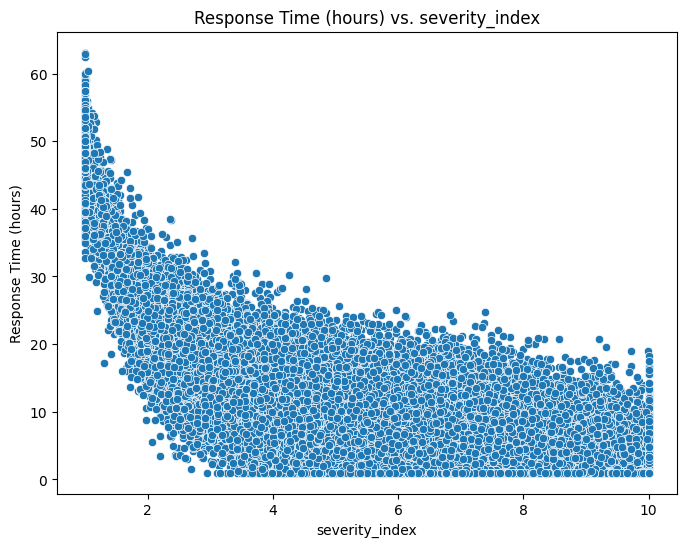

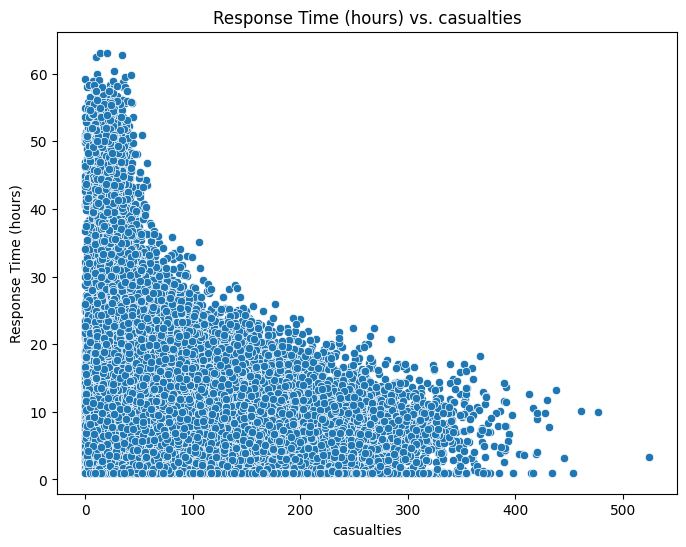

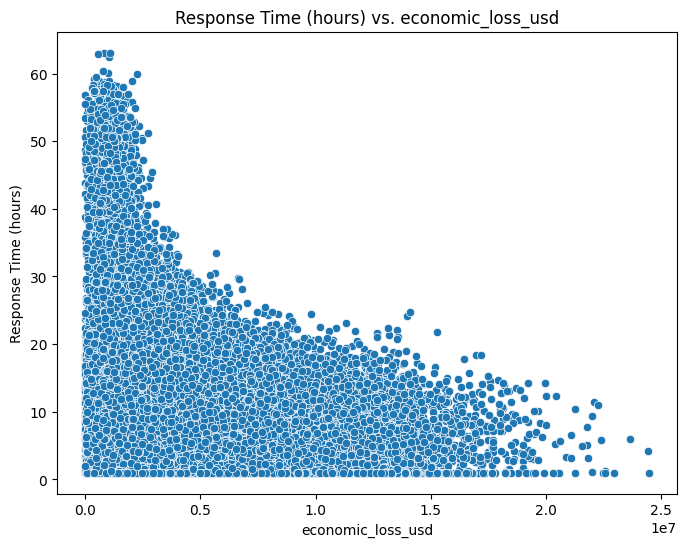

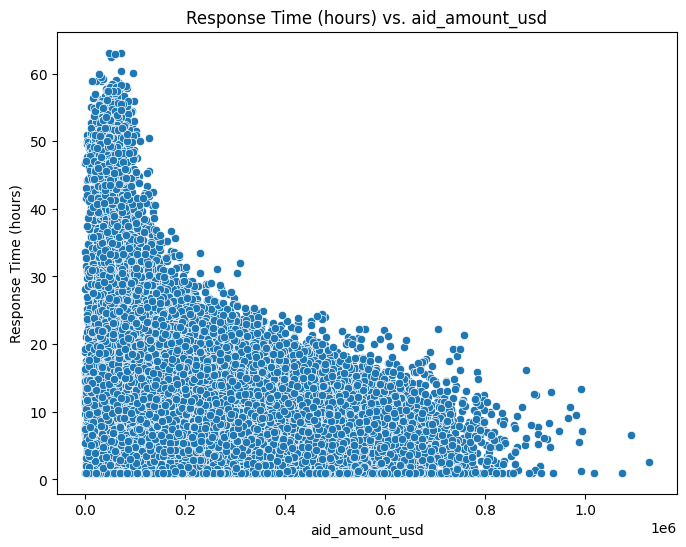

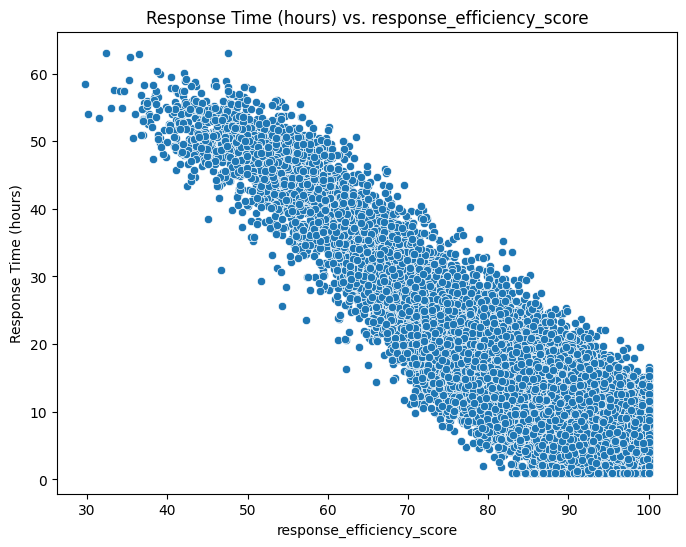

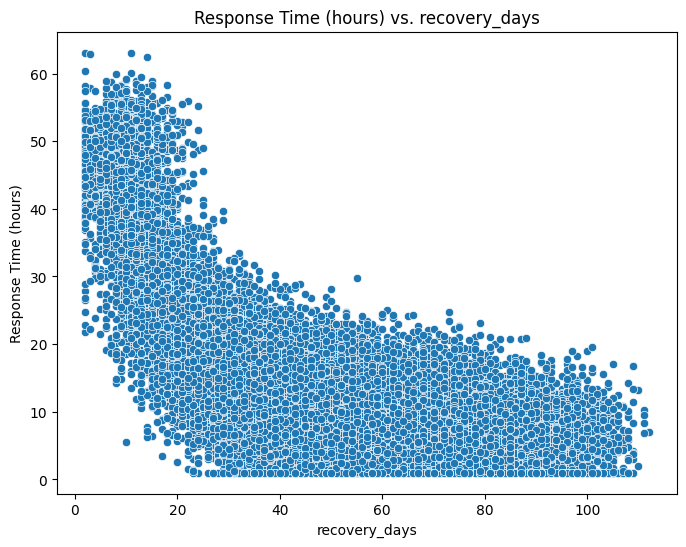

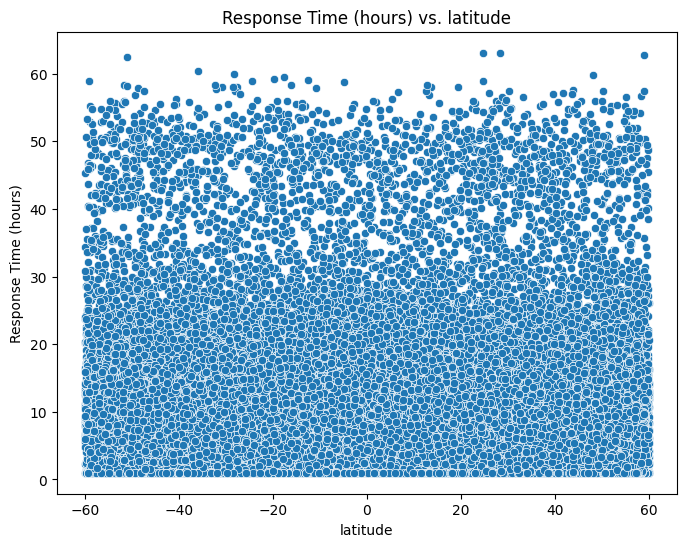

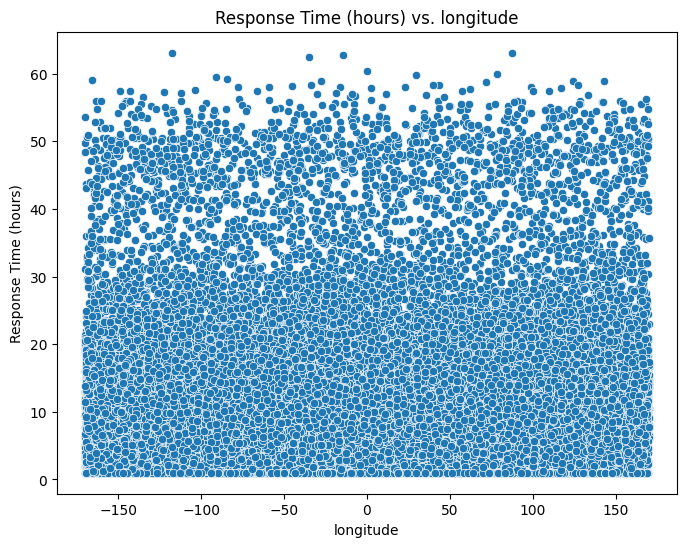


Visualizing categorical columns against response_time_hours using box plots:
Skipping box plot for 'date' due to too many unique categories (2557).
Skipping box plot for 'country' due to too many unique categories (20).


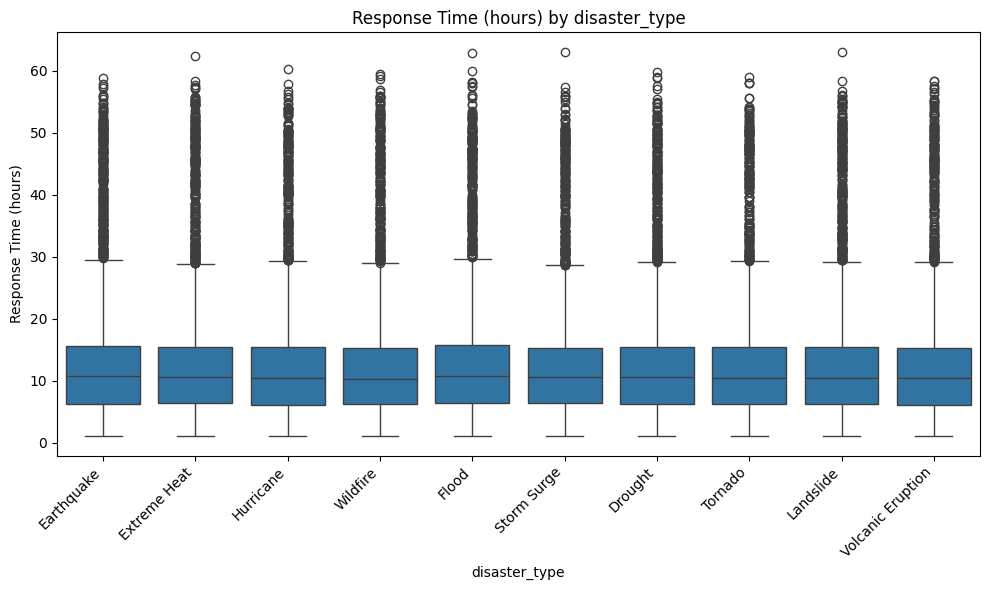

In [87]:
# Separate numerical and categorical columns for visualization
numerical_cols = df.select_dtypes(include=np.number).columns.drop('response_time_hours', errors='ignore')
categorical_cols = df.select_dtypes(include='object').columns

print("Visualizing numerical columns against response_time_hours using scatter plots:")
# Visualize numerical columns vs. response_time_hours (scatter plots)
for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=col, y='response_time_hours', data=df)
    plt.title(f'Response Time (hours) vs. {col}')
    plt.xlabel(col)
    plt.ylabel('Response Time (hours)')
    plt.show()

print("\nVisualizing categorical columns against response_time_hours using box plots:")
# Visualize categorical columns vs. response_time_hours (box plots)
for col in categorical_cols:
    # Skip columns with too many unique values for readable box plots
    if df[col].nunique() < 20: # Heuristic threshold for plotting readability
        plt.figure(figsize=(10, 6))
        sns.boxplot(x=col, y='response_time_hours', data=df)
        plt.title(f'Response Time (hours) by {col}')
        plt.xlabel(col)
        plt.ylabel('Response Time (hours)')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Skipping box plot for '{col}' due to too many unique categories ({df[col].nunique()}).")

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   date                       50000 non-null  object 
 1   country                    50000 non-null  object 
 2   disaster_type              50000 non-null  object 
 3   severity_index             50000 non-null  float64
 4   casualties                 50000 non-null  int64  
 5   economic_loss_usd          50000 non-null  float64
 6   response_time_hours        50000 non-null  float64
 7   aid_amount_usd             50000 non-null  float64
 8   response_efficiency_score  50000 non-null  float64
 9   recovery_days              50000 non-null  int64  
 10  latitude                   50000 non-null  float64
 11  longitude                  50000 non-null  float64
dtypes: float64(7), int64(2), object(3)
memory usage: 4.6+ MB


Number of unique countries: 20


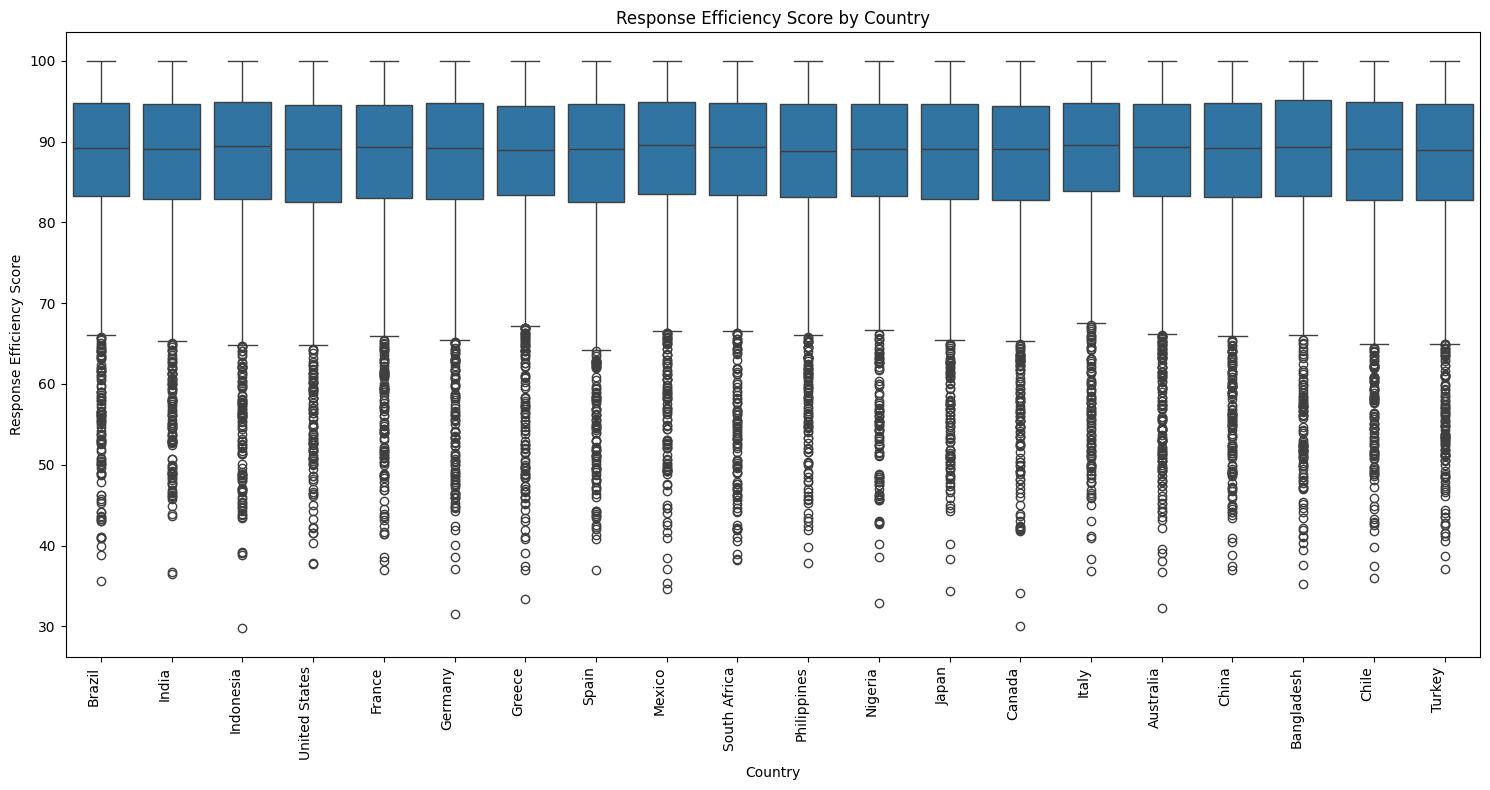

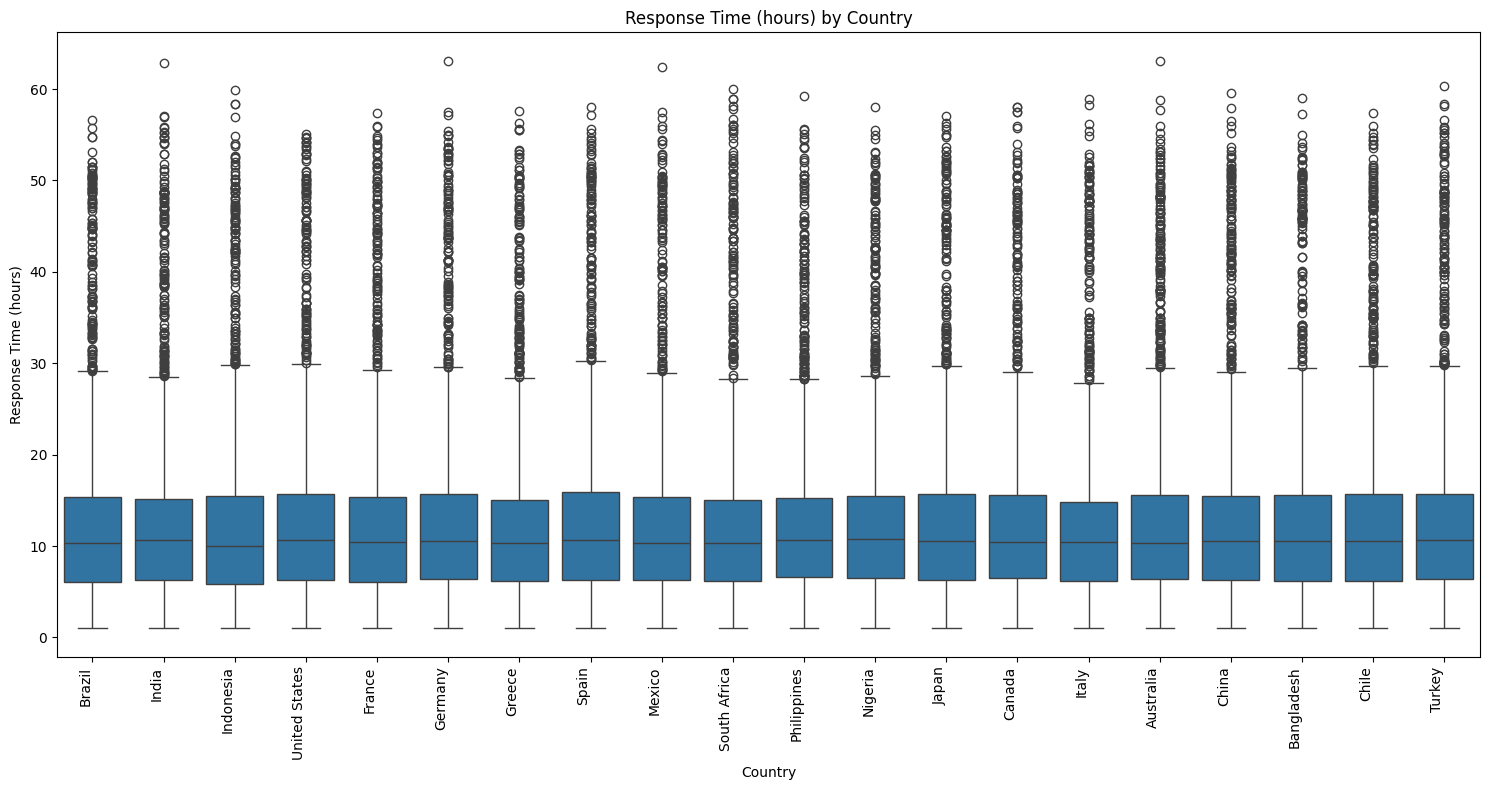

In [89]:
# Check the number of unique countries to decide on plotting strategy
num_countries = df['country'].nunique()
print(f"Number of unique countries: {num_countries}")

# If there are too many countries, plotting all of them might be unreadable.
# For demonstration, we'll plot for all unique countries, but advise on potential readability issues.

# Plotting Country vs Response Efficiency Score
plt.figure(figsize=(15, 8))
sns.boxplot(x='country', y='response_efficiency_score', data=df)
plt.title('Response Efficiency Score by Country')
plt.xlabel('Country')
plt.ylabel('Response Efficiency Score')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

# Plotting Country vs Response Time Hours
plt.figure(figsize=(15, 8))
sns.boxplot(x='country', y='response_time_hours', data=df)
plt.title('Response Time (hours) by Country')
plt.xlabel('Country')
plt.ylabel('Response Time (hours)')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

In [90]:
df.drop(['date','country'],inplace = True,axis=1)

In [91]:
df.columns

Index(['disaster_type', 'severity_index', 'casualties', 'economic_loss_usd',
       'response_time_hours', 'aid_amount_usd', 'response_efficiency_score',
       'recovery_days', 'latitude', 'longitude'],
      dtype='object')

In [92]:
X = df.drop('response_time_hours', axis=1)
y = df['response_time_hours']

In [93]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [94]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

### Preprocessing: One-Hot Encoding and Scaling

First, we'll apply one-hot encoding to the `disaster_type` categorical feature. Then, we'll scale the numerical features using `StandardScaler` to ensure they contribute equally to the model.

In [95]:
# Identify categorical and numerical columns in X_train
categorical_cols = X_train.select_dtypes(include='object').columns
numerical_cols = X_train.select_dtypes(include=np.number).columns

# Apply One-Hot Encoding to categorical columns
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns - crucial after one-hot encoding, especially if some categories are missing in train/test
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# Scale numerical columns
scaler = StandardScaler()
X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train_encoded[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test_encoded[numerical_cols])

print("Preprocessing complete. Data is ready for model training.")

Preprocessing complete. Data is ready for model training.


### Train RandomForestRegressor Model

Now, we'll train a `RandomForestRegressor` model on the preprocessed training data. Random Forests are powerful ensemble methods suitable for regression tasks.

In [96]:
# Initialize and train the RandomForestRegressor model
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 to use all available cores
model.fit(X_train_scaled, y_train)

print("RandomForestRegressor model trained successfully.")

RandomForestRegressor model trained successfully.


### Evaluate Model Performance

Finally, we'll make predictions on the test set and evaluate the model's performance using Mean Squared Error (MSE) and R-squared (R2) score.

Mean Squared Error (MSE): 12.05
R-squared (R2) Score: 0.85


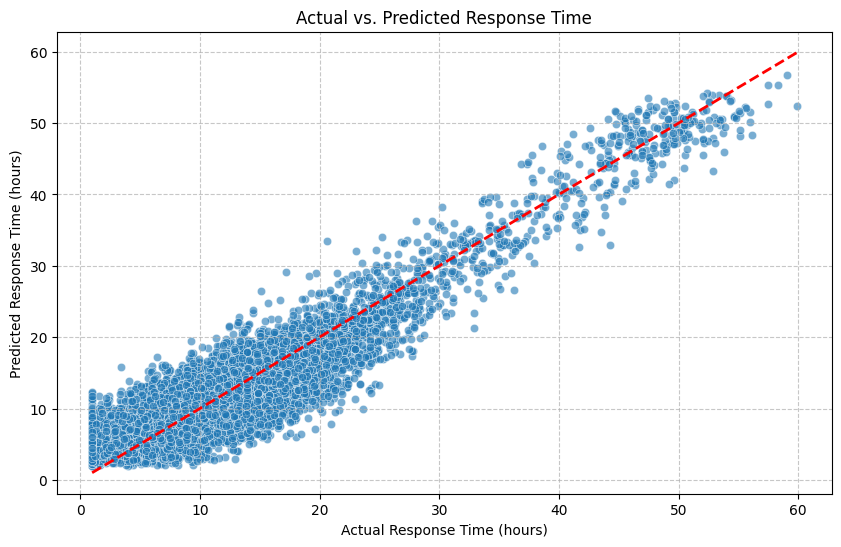

In [97]:
# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

# Optional: Visualize predictions vs actual values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Response Time (hours)')
plt.ylabel('Predicted Response Time (hours)')
plt.title('Actual vs. Predicted Response Time')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
